# Simulação Computacional: Sequências Fundamentais

Neste experimento, geramos as quatro sequências discretas fundamentais para a análise de sistemas lineares.
Para manter a coerência com o estudo da rede elétrica, utilizamos a nossa onda de tensão como base para a senoide, e modelamos as demais sequências em um intervalo de amostras $n \in [-5, 20]$.

*   **Impulso Unitário ($\delta[n]$):** O elemento neutro da convolução.
*   **Degrau Unitário ($u[n]$):** Representa o "ligar" de um sistema.
*   **Exponencial Real ($a^n u[n]$):** Com $a = 0{,}85$, modela um transitório de amortecimento.
*   **Senoide Discreta:** Sinal da rede com $f_s = 480\,\text{Hz}$ ($\omega_0 = \pi/4$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

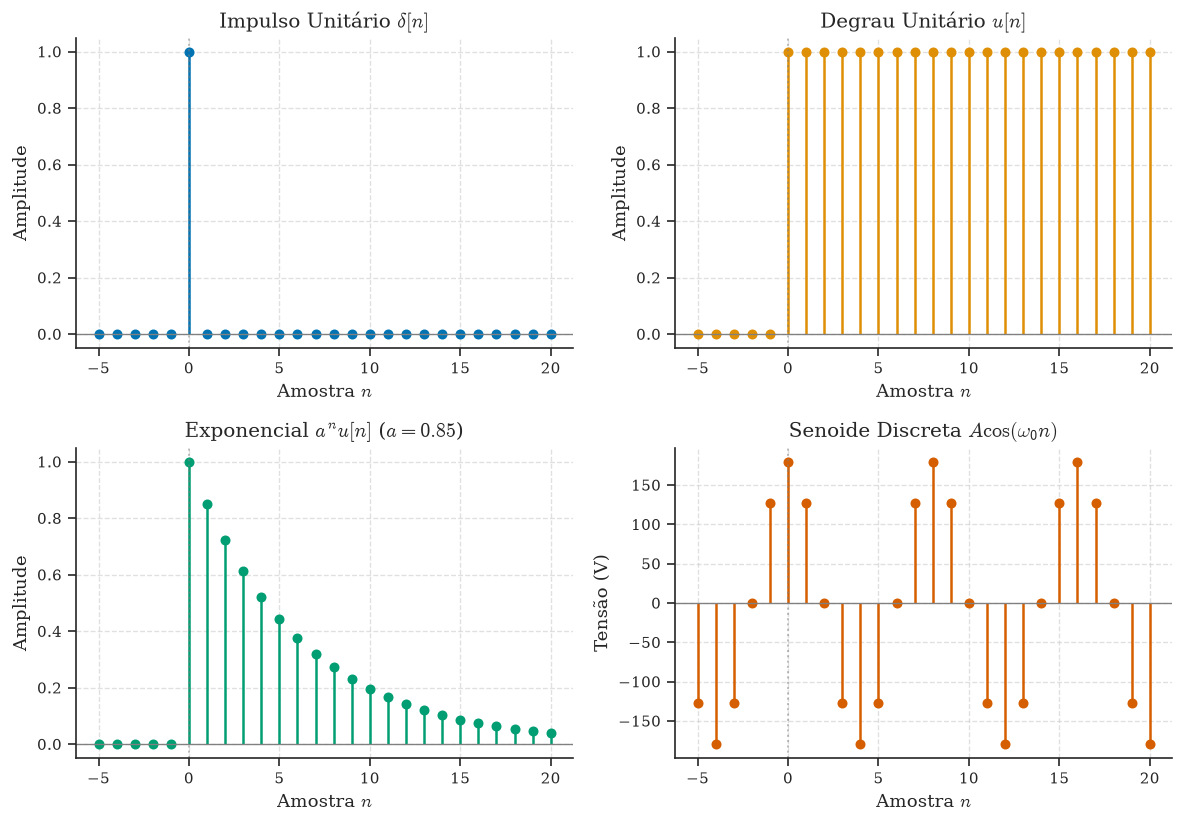

In [2]:
# Vetor de amostras n (índices)
n = np.arange(-5, 21)

# 1. Impulso Unitário: d[n]
impulso = np.where(n == 0, 1.0, 0.0)

# 2. Degrau Unitário: u[n]
degrau = np.where(n >= 0, 1.0, 0.0)

# 3. Exponencial: a^n * u[n]
a = 0.85
exponencial = (a**n) * degrau

# 4. Senoide Discreta (Rede Elétrica)
# A = 179.6 V, f0 = 60 Hz, fs = 480 Hz -> w0 = 2*pi*(60/480) = pi/4
A = 179.6
w0 = np.pi / 4
senoide = A * np.cos(w0 * n)

# Configuração da Figura (Painel 2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
cores = sns.color_palette("colorblind")

sequencias = [
    (axes[0, 0], impulso, r"Impulso Unitário $\delta[n]$", cores[0], "Amplitude"),
    (axes[0, 1], degrau, r"Degrau Unitário $u[n]$", cores[1], "Amplitude"),
    (axes[1, 0], exponencial, rf"Exponencial $a^n u[n]$ ($a={a}$)", cores[2], "Amplitude"),
    (axes[1, 1], senoide, r"Senoide Discreta $A\cos(\omega_0 n)$", cores[3], "Tensão (V)")
]

for ax, seq, titulo, cor, ylabel in sequencias:
    markerline, stemlines, baseline = ax.stem(
        n, seq, linefmt="-", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, color=cor, linewidth=1.5)
    plt.setp(markerline, color=cor, markersize=5)
    
    # Destacar o eixo n=0
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"Amostra $n$")
    # Forçar ticks inteiros no eixo x
    ax.set_xticks(np.arange(-5, 21, 5))

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_sequencias.png")
plt.show()